# Лабораторная работа №2
## Губанова Елена Борисовна
###Вариант №5


# **Задача 2.1.**  
Функция **y = f(x)** задана таблицей значений **y<sub>0</sub>, y<sub>1</sub>, …, y<sub>n</sub>** в точках **x<sub>0</sub>, x<sub>1</sub>, …, x<sub>n</sub>**.  

Используя **метод наименьших квадратов (МНК)**, найти многочлен  
**P<sub>m</sub>(x) = a<sub>0</sub> + a<sub>1</sub>x + … + a<sub>m</sub>x<sup>m</sup>** наилучшего среднеквадратичного приближения оптимальной степени **m = m\***.  

**Критерий выбора m\*:**  
Оптимальная степень **m\*** — это минимальная степень, начиная с которой величина  
$$
\sigma_m = \sqrt{\frac{1}{n - m} \sum_{k=0}^{n} \left( P_m(x_k) - y_k \right)^2}
$$  
стабилизируется или начинает возрастать.  

---

### **Порядок решения задачи:**  

1. **Исходные данные:**  
   Задать векторы **x** и **y** (табличные значения функции).  

2. **Реализация МНК:**  
   - Реализовать метод наименьших квадратов **без использования встроенных функций**.  
   - Найти многочлены **P<sub>m</sub>(x)** для степеней **m = 0, 1, 2, …**  
   - Вычислить значения **σ<sub>m</sub>** для каждого многочлена.  

3. **Анализ результатов:**  
   - Построить гистограмму зависимости **σ<sub>m</sub>** от **m**.  
   - Выбрать оптимальную степень **m\*** на основе стабилизации или роста **σ<sub>m</sub>**.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([-2.1, -1.8, -1.5, -1.2, -0.9, -0.6, -0.3, 0, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1])
y = np.array([14.1982, 11.4452, 9.1586, 7.2426, 6.3640, 4.8182, 6.1088, 3.9536, 4.6872, 4.7601, 5.8511, 7.1010, 9.1792, 11.421, 14.097])

n = len(x) - 1  # число узлов
max_m = min(n, 10)  # разумный максимум для степени многочлена
sigmas = []

In [4]:
def least_squares_fit(x, y, m):
    N = len(x)
    A = np.zeros((m+1, m+1))
    b = np.zeros(m+1)
    # Формируем систему нормальных уравнений
    for i in range(m+1):
        for j in range(m+1):
            A[i][j] = sum(x**(i+j))
        b[i] = sum(y * (x**i))
    # Решаем СЛАУ методом Гаусса
    a = gaussian_elimination(A, b)
    return a

In [5]:
def gaussian_elimination(A, b):
    A = A.copy()
    b = b.copy()
    n = len(b)

    for i in range(n):
        # Поиск максимального элемента в столбце
        max_row = i + np.argmax(np.abs(A[i:, i]))
        A[[i, max_row]] = A[[max_row, i]]
        b[i], b[max_row] = b[max_row], b[i]
        # Прямой ход
        for j in range(i+1, n):
            factor = A[j][i] / A[i][i]
            A[j, i:] -= factor * A[i, i:]
            b[j] -= factor * b[i]
    # Обратный ход
    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i+1:], x[i+1:])) / A[i][i]
    return x

In [6]:
def compute_sigma(x, y, a):
    m = len(a) - 1
    n = len(x) - 1
    residuals = []
    for xi, yi in zip(x, y):
        pi = sum(a[j] * xi**j for j in range(len(a)))
        residuals.append((pi - yi)**2)
    sigma = np.sqrt(sum(residuals) / (n - m))
    return sigma

In [7]:
coefficients = []
for m in range(0, max_m + 1):
    a = least_squares_fit(x, y, m)
    sigma = compute_sigma(x, y, a)
    sigmas.append(sigma)
    coefficients.append(a)
# Определение оптимальной степени для m*
opt_m = None
for i in range(1, len(sigmas) - 1):
    if sigmas[i+1] >= sigmas[i]:
        opt_m = i
        break
if opt_m is None:
    opt_m = max_m
print(f"Оптимальная степень многочлена m* = {opt_m}")

Оптимальная степень многочлена m* = 2


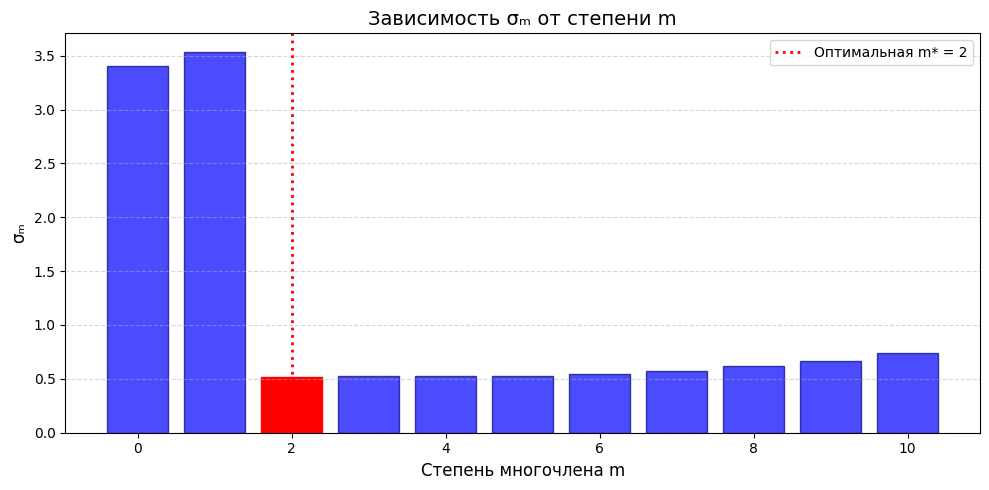

In [10]:
plt.figure(figsize=(10, 5))
bars = plt.bar(range(0, max_m+1), sigmas,
               color='blue',
               edgecolor='navy',
               alpha=0.7)

# Выделение оптимальной степени
opt_bar = bars[opt_m]
opt_bar.set_color('red')
opt_bar.set_alpha(1)

plt.axvline(opt_m, color='red', linestyle=':', linewidth=2,
            label=f'Оптимальная m* = {opt_m}')


plt.xlabel("Степень многочлена m", fontsize=12)
plt.ylabel("σₘ", fontsize=12)
plt.title("Зависимость σₘ от степени m", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# **Задача 2.2.**  
Приближение функции интерполяционными многочленами Лагранжа

## **Условие задачи**
Дана функция **y = f(x)**. Требуется:
1. Приблизить **f(x)** на отрезке **[a, b]** многочленами Лагранжа **1-й, 2-й и 3-й степеней**.
2. Построить на одном графике:
   - Исходную функцию **f(x)**
   - Все три интерполяционных многочлена
3. Для многочлена **3-й степени** дополнительно:
   - Сравнить качество приближения при разном выборе узлов интерполяции

---


In [11]:
def f(x):
    return 4**(np.cos(x))

In [12]:
def lagrange_poly(x_nodes, y_nodes, x_vals):
    n = len(x_nodes)
    result = np.zeros_like(x_vals)
    for i in range(n):
        li = np.ones_like(x_vals)
        for j in range(n):
            if i != j:
                li *= (x_vals - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        result += y_nodes[i] * li
    return result

In [13]:
a = 0.5
b = 1.5
x_plot = np.linspace(a, b, 500)
y_plot = f(x_plot)

In [14]:
def equidistant_nodes(a, b, degree):
    return np.linspace(a, b, degree + 1)

def chebyshev_nodes(a, b, degree):
    i = np.arange(degree + 1)
    x = np.cos((2*i + 1) * np.pi / (2 * (degree + 1)))
    return 0.5 * (a + b) + 0.5 * (b - a) * x[::-1]  # от -1 к 1 в [a, b]

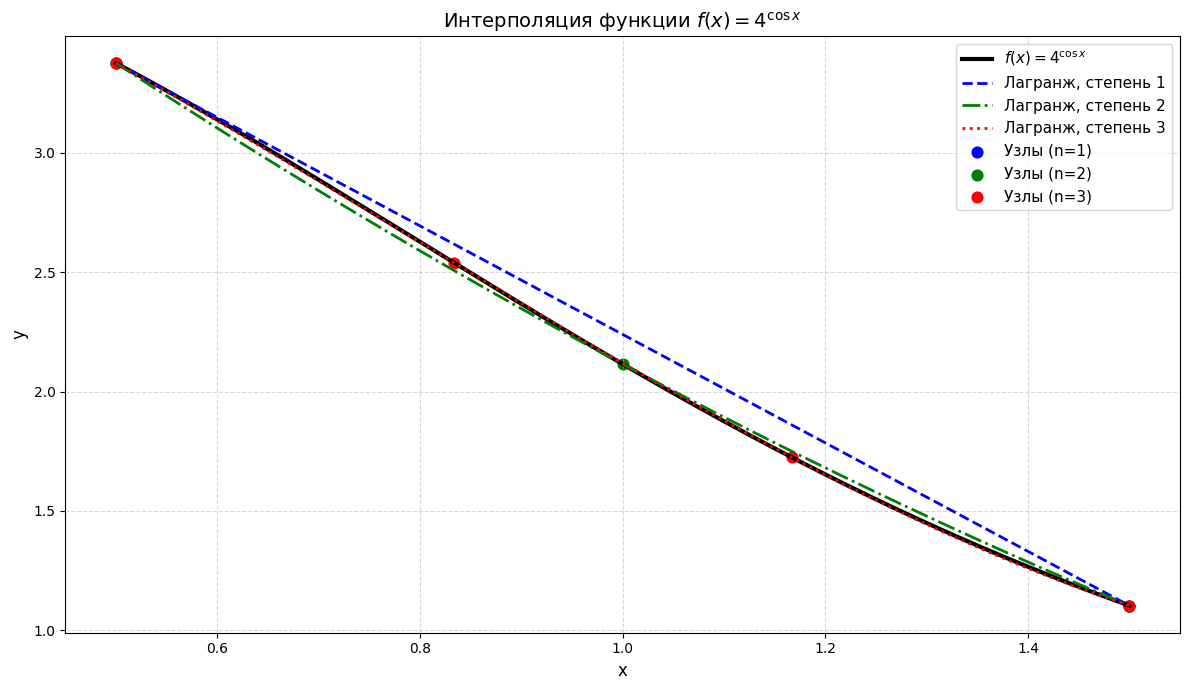

In [16]:
plt.figure(figsize=(12, 7))

# Основной график функции
plt.plot(x_plot, y_plot,
         color='black',
         linestyle='-',
         linewidth=3,
         label='$f(x) = 4^{\cos x}$')
styles = {
    1: {'color': 'blue', 'linestyle': '--', 'linewidth': 2},
    2: {'color': 'green', 'linestyle': '-.', 'linewidth': 2},
    3: {'color': 'red', 'linestyle': ':', 'linewidth': 2}
}

# Построение интерполяционных кривых
for deg in range(1, 4):
    x_nodes = equidistant_nodes(a, b, deg)
    y_nodes = f(x_nodes)
    y_interp = lagrange_poly(x_nodes, y_nodes, x_plot)
    plt.plot(x_plot, y_interp,
             **styles[deg],
             label=f'Лагранж, степень {deg}')

# Узлы интерполяции
for deg in range(1, 4):
    x_nodes = equidistant_nodes(a, b, deg)
    plt.scatter(x_nodes, f(x_nodes),
                color=styles[deg]['color'],
                s=60,
                label=f'Узлы (n={deg})')

# Оформление графика
plt.title("Интерполяция функции $f(x) = 4^{\cos x}$", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)

# Сетка и легенда
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

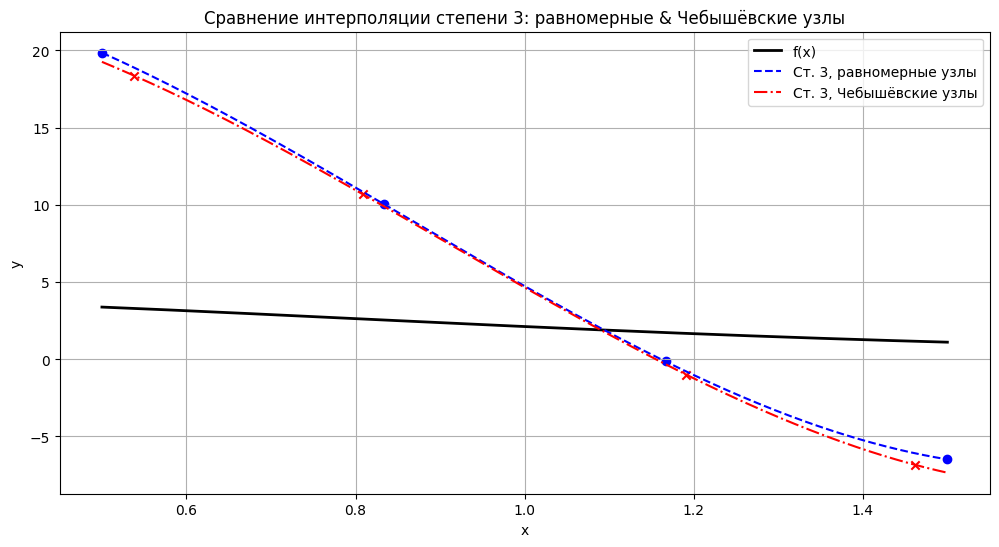

In [30]:
x_nodes_eq = equidistant_nodes(a, b, 3)
x_nodes_ch = chebyshev_nodes(a, b, 3)

y_nodes_eq = f(x_nodes_eq)
y_nodes_ch = f(x_nodes_ch)

interp_eq = lagrange_poly(x_nodes_eq, y_nodes_eq, x_plot)
interp_ch = lagrange_poly(x_nodes_ch, y_nodes_ch, x_plot)

plt.figure(figsize=(12, 6))
plt.plot(x_plot, y_plot, 'k-', label='f(x)', linewidth=2)
plt.plot(x_plot, interp_eq, 'b--', label='Ст. 3, равномерные узлы')
plt.plot(x_plot, interp_ch, 'r-.', label='Ст. 3, Чебышёвские узлы')
plt.scatter(x_nodes_eq, y_nodes_eq, color='blue', marker='o')
plt.scatter(x_nodes_ch, y_nodes_ch, color='red', marker='x')
plt.title("Сравнение интерполяции степени 3: равномерные & Чебышёвские узлы")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# **Задача 2.3.**  
Приближение функции методом глобальной интерполяции и сплайнами

## **Постановка задачи**
Дана функция **y = f(x)**. Требуется:
1. Приблизить **f(x)** на отрезке **[a, b]**:
   - Методом глобальной интерполяции
   - Указанным в варианте типом сплайна
2. Построить на одном графике:
   - Исходную функцию **f(x)**
   - Приближающие функции
3. Сравнить качество приближения при разном количестве узлов интерполяции

---

In [19]:
from scipy.interpolate import CubicHermiteSpline

In [23]:
def f(x):
    return 10 * np.cos(x**3) / x

# 2. Производная функции
def df(x):
    return 10*(-1* np.sin(x**3) * 3*x**3 -np.cos(x**3))/x**2

In [24]:
def lagrange_poly(x_nodes, y_nodes, x_vals):
    n = len(x_nodes)
    result = np.zeros_like(x_vals)
    for i in range(n):
        li = np.ones_like(x_vals)
        for j in range(n):
            if i != j:
                li *= (x_vals - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
        result += y_nodes[i] * li
    return result

In [27]:
x_dense = np.linspace(3, 5, 500)
y_true = f(x_dense)
# Узлы для сравнения
nodes_list = [5, 10, 15]

In [39]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()


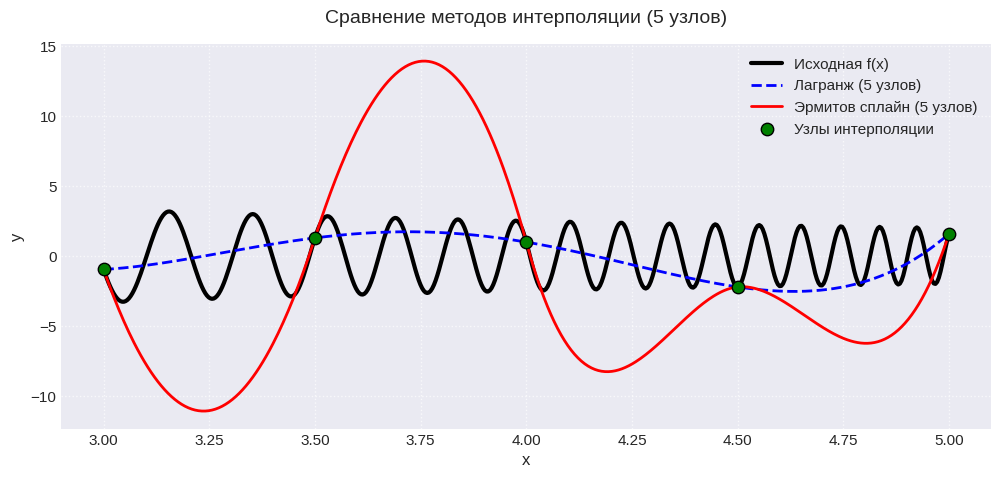

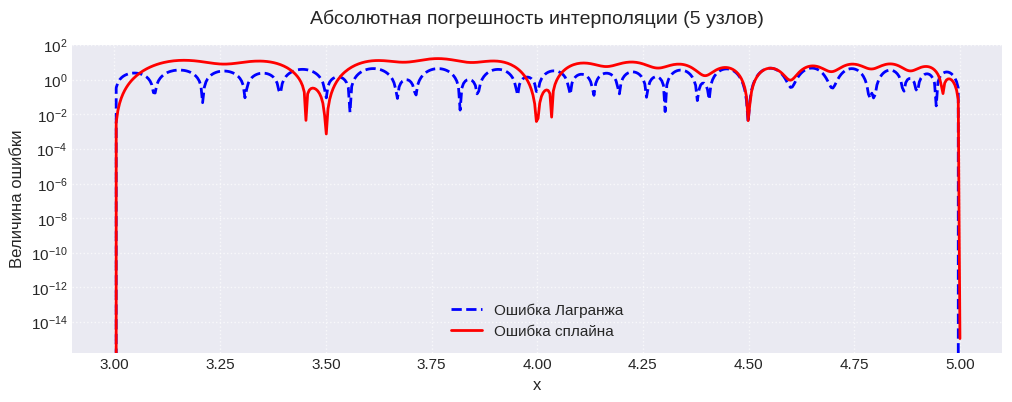

Результаты для 5 узлов:
  Макс. ошибка Лагранжа: 4.675e+00
  Макс. ошибка сплайна: 1.655e+01
──────────────────────────────────────────────────


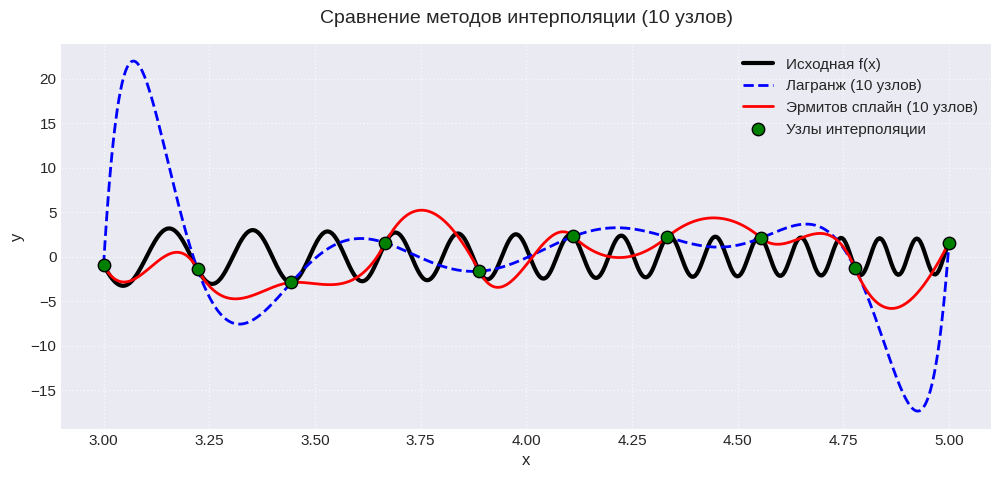

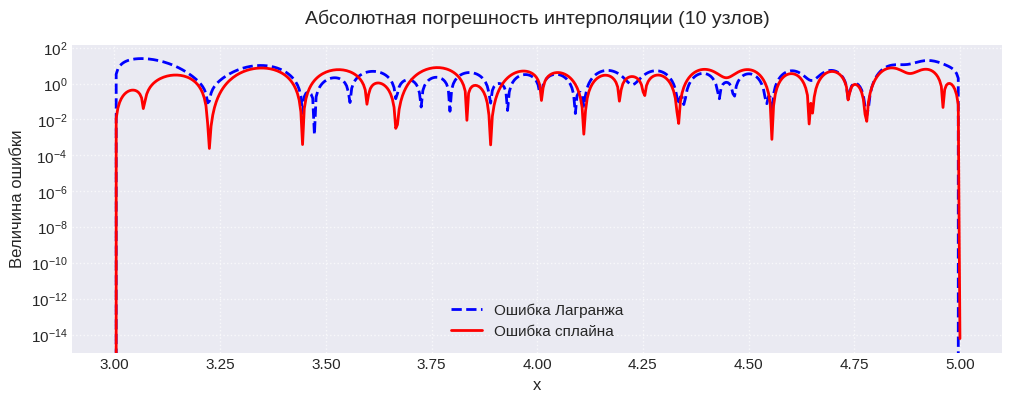

Результаты для 10 узлов:
  Макс. ошибка Лагранжа: 2.474e+01
  Макс. ошибка сплайна: 7.797e+00
──────────────────────────────────────────────────


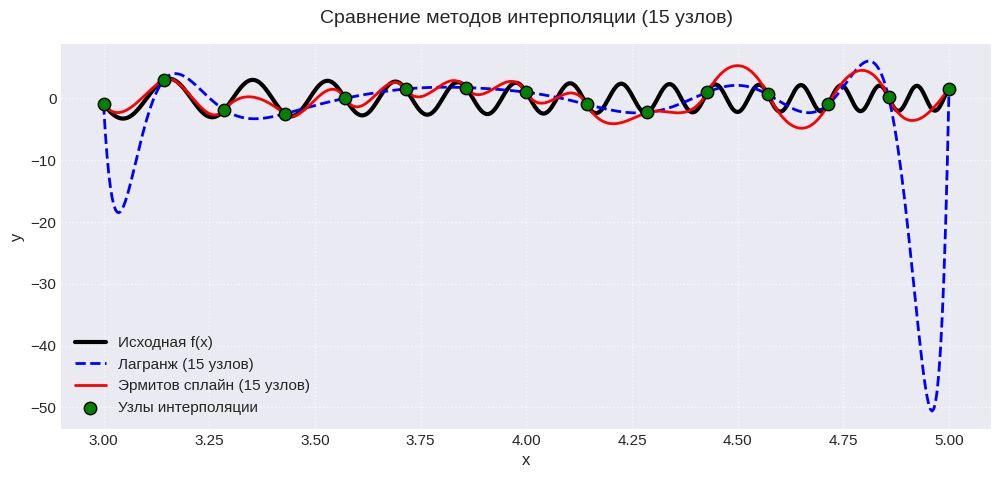

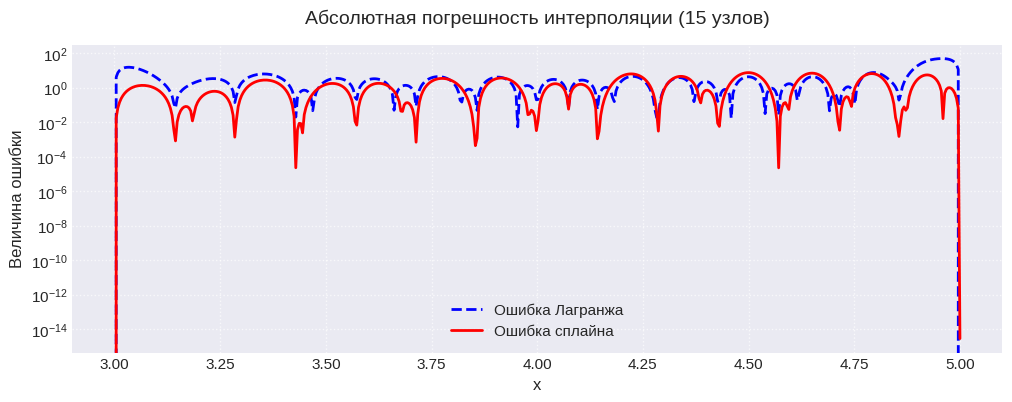

Результаты для 15 узлов:
  Макс. ошибка Лагранжа: 4.891e+01
  Макс. ошибка сплайна: 7.504e+00
──────────────────────────────────────────────────


In [41]:
plt.style.use('seaborn-v0_8-darkgrid')
for n_nodes in nodes_list:
    x_nodes = np.linspace(3, 5, n_nodes)
    y_nodes = f(x_nodes)
    dy_nodes = df(x_nodes)

    # Построение приближающих функций
    y_lagr = lagrange_poly(x_nodes, y_nodes, x_dense)
    spline = CubicHermiteSpline(x_nodes, y_nodes, dy_nodes)
    y_spline = spline(x_dense)

    # 1. График интерполяции
    plt.figure(figsize=(12, 5))

    # Основная функция
    plt.plot(x_dense, y_true, 'black', linewidth=3, label='Исходная f(x)')

    # Интерполяционные методы
    plt.plot(x_dense, y_lagr, 'blue', linestyle='--', linewidth=2,
             label=f'Лагранж ({n_nodes} узлов)')
    plt.plot(x_dense, y_spline, 'red', linestyle='-', linewidth=2,
             label=f'Эрмитов сплайн ({n_nodes} узлов)')

    # Узлы интерполяции
    plt.scatter(x_nodes, y_nodes, color='green', s=80,
               edgecolor='black', zorder=5, label='Узлы интерполяции')

    # Оформление
    plt.title(f'Сравнение методов интерполяции ({n_nodes} узлов)', fontsize=14, pad=15)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.legend(fontsize=11, framealpha=1, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

    # 2. График погрешностей
    err_lagr = np.abs(y_lagr - y_true)
    err_spline = np.abs(y_spline - y_true)

    plt.figure(figsize=(12, 4))
    plt.plot(x_dense, err_lagr, 'blue', linestyle='--', linewidth=2,
             label='Ошибка Лагранжа')
    plt.plot(x_dense, err_spline, 'red', linestyle='-', linewidth=2,
             label='Ошибка сплайна')

    # Оформление
    plt.title(f'Абсолютная погрешность интерполяции ({n_nodes} узлов)', fontsize=14, pad=15)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Величина ошибки', fontsize=12)
    plt.yscale('log')  # Логарифмическая шкала для лучшего отображения
    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.legend(fontsize=11)
    plt.show()

    # 3. Численные значения
    max_err_lagr = np.max(err_lagr)
    max_err_spline = np.max(err_spline)
    print(f"Результаты для {n_nodes} узлов:")
    print(f"  Макс. ошибка Лагранжа: {max_err_lagr:.3e}")
    print(f"  Макс. ошибка сплайна: {max_err_spline:.3e}")
    print('─' * 50)

#**Задача 2.4**
# Решение системы ОДУ 1 порядка неявным методом Эйлера

## Постановка задачи
Необходимо:
1. Составить программу-функцию для решения системы ОДУ 1 порядка с постоянными коэффициентами по неявному методу Эйлера
2. Использовать программу для решения жесткой задачи с шагом h=0.01
3. Построить графики компонент полученного решения

In [42]:
n_terms = 300
a = 0
b = 3
eps = 1e-4

In [43]:
def f(x):
    x = np.asarray(x)
    result = np.zeros_like(x, dtype=float)
    for n in range(1, n_terms + 1):
        result += ( np.sin(3* n * x)) / (n**3-0.5)
    return result

In [44]:
def bisection_extremum(f, a, b, eps, find_max=False):
    while (b - a) > eps:
        x1 = a + (b - a) / 3
        x2 = b - (b - a) / 3
        f1, f2 = f(x1), f(x2)
        if find_max:
            if f1 < f2:
                a = x1
            else:
                b = x2
        else:
            if f1 > f2:
                a = x1
            else:
                b = x2
    x_opt = (a + b) / 2
    return x_opt, f(x_opt)

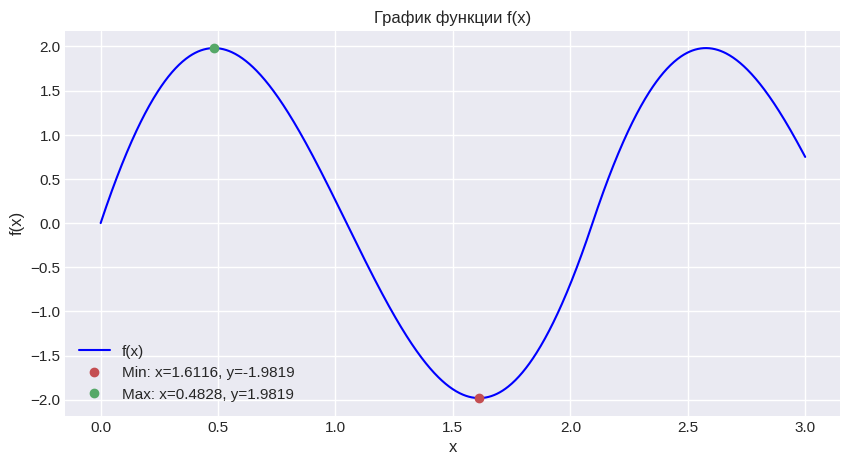

In [47]:
plt.style.use('seaborn-v0_8-darkgrid')
x_vals = np.linspace(a, b, 1000)
y_vals = f(x_vals)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='f(x)', color='blue')
plt.title('График функции f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
x_min, y_min = bisection_extremum(f, a, b, eps, find_max=False)
x_max, y_max = bisection_extremum(f, a, b, eps, find_max=True)

# Отобразим точки экстремумов
plt.plot(x_min, y_min, 'ro', label=f'Min: x={x_min:.4f}, y={y_min:.4f}')
plt.plot(x_max, y_max, 'go', label=f'Max: x={x_max:.4f}, y={y_max:.4f}')
plt.legend()
plt.show()

In [48]:
# Вывод численных результатов
print(f"Минимум: x = {x_min:.6f}, f(x) = {y_min:.6f}")
print(f"Максимум: x = {x_max:.6f}, f(x) = {y_max:.6f}")

Минимум: x = 1.611596, f(x) = -1.981935
Максимум: x = 0.482780, f(x) = 1.981935


## **Задача 2.5**
# Задача 2.5. Минимизация квадратичной функции методом Ньютона

## Формулировка задачи
Необходимо:
1. Найти минимум квадратичной функции:
   $$f(x,y) = a_{11}x^2 + 2a_{12}xy + a_{22}y^2 + 2a_{13}x + 2a_{23}y$$
2. Точность вычислений: $\epsilon = 10^{-6}$
3. Использовать метод Ньютона для одномерной минимизации
4. Построить график функции $f(x,y)$
5. Подсчитать количество итераций для достижения заданной точности

## Алгоритм решения

1. Вычислить градиент функции:
   $$\nabla f = \begin{bmatrix}
   2a_{11}x + 2a_{12}y + 2a_{13} \\
   2a_{12}x + 2a_{22}y + 2a_{23}
   \end{bmatrix}$$

2. Вычислить гессиан:
   $$H = \begin{bmatrix}
   2a_{11} & 2a_{12} \\
   2a_{12} & 2a_{22}
   \end{bmatrix}$$

3. Итерационная формула метода Ньютона:
   $$x_{k+1} = x_k - H^{-1}\nabla f(x_k)$$

4. Критерий остановки:
   $$||\nabla f(x_k)|| < \epsilon$$


Результаты минимизации:
Точка минимума: (0.97419355, 3.01290322)
Значение функции в минимуме: -9.80258065
Количество итераций: 6
Значение градиента в минимуме: (4.35e-08, 0.00e+00)


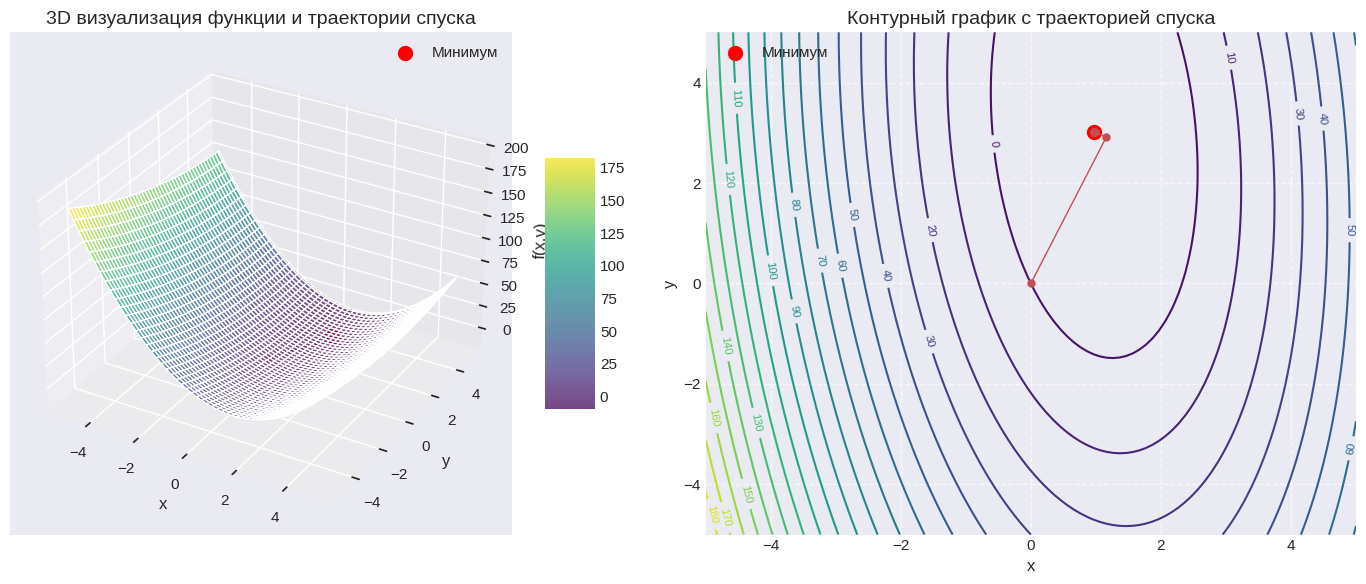

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Уточненные коэффициенты квадратичной функции
a11 = 4      # коэффициент при x²
a12 = 0.25   # так как 2a12=0.5  a12=0.25
a22 = 0.5    # коэффициент при y²
a13 = -4.65  # так как 2a13=-9.3  a13=-4.65
a23 = -1.75  # так как 2a23=-3.5  a23=-1.75

def f(x, y):
    """Квадратичная функция"""
    return a11*x**2 + 2*a12*x*y + a22*y**2 + 2*a13*x + 2*a23*y

def df_dx(x, y):
    """Производная по x"""
    return 2*a11*x + 2*a12*y + 2*a13

def df_dy(x, y):
    """Производная по y"""
    return 2*a12*x + 2*a22*y + 2*a23

def coordinate_descent(x0, y0, epsilon=1e-6, max_iter=1000):
    """Метод покоординатного спуска"""
    x, y = x0, y0
    iterations = 0
    path = [(x, y)]

    for _ in range(max_iter):
        # Оптимизация по x (фиксируем y)
        x = (-2*a12*y - 2*a13) / (2*a11)

        # Оптимизация по y (фиксируем x)
        y = (-2*a12*x - 2*a23) / (2*a22)

        path.append((x, y))
        iterations += 1

        # Проверка условия сходимости
        if np.sqrt(df_dx(x, y)**2 + df_dy(x, y)**2) < epsilon:
            break

    return x, y, iterations, path

# Начальная точка
x0, y0 = 0.0, 0.0

# Поиск минимума
x_min, y_min, n_iter, path = coordinate_descent(x0, y0)

print("Результаты минимизации:")
print(f"Точка минимума: ({x_min:.8f}, {y_min:.8f})")
print(f"Значение функции в минимуме: {f(x_min, y_min):.8f}")
print(f"Количество итераций: {n_iter}")
print(f"Значение градиента в минимуме: ({df_dx(x_min, y_min):.2e}, {df_dy(x_min, y_min):.2e})")

# Визуализация
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Траектория спуска
path_x, path_y = zip(*path)

fig = plt.figure(figsize=(14, 6))

# 3D график
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)
ax1.plot(path_x, path_y, [f(x,y) for x,y in path], 'r.-', markersize=10, linewidth=1)
ax1.scatter(x_min, y_min, f(x_min, y_min), c='red', s=100, label='Минимум')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_zlabel('f(x,y)', fontsize=12)
ax1.set_title('3D визуализация функции и траектории спуска', fontsize=14)
ax1.legend()

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(path_x, path_y, 'r.-', markersize=10, linewidth=1)
ax2.scatter(x_min, y_min, c='red', s=100, label='Минимум')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_title('Контурный график с траекторией спуска', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

## **Задача 2.6**

Решить приближённо задачу Коши для ОДУ 3-го порядка:


$a_0 y''' + a_1 y'' + a_2 y' + a_3 y = f(t)$

$y(A)=b_1,\quad y'(A) = b_2,\quad y''(A) = b_3$


на отрезке \([A, B]\), используя **метод Рунге-Кутты 4-го порядка** Оценить погрешность по правилу Рунге. Построить график.

In [50]:
a0 = 1
a1 = -2.4
a2 = 0.09
a3 = 48.87

In [51]:
# Правая часть
def f_rhs(t):
    return np.sin( t) - 7 * t + 2

# Система ОДУ 1-го порядка
def system(t, y):
    y1, y2, y3 = y
    dy1 = y2
    dy2 = y3
    dy3 = (f_rhs(t) - a1 * y3 - a2 * y2 - a3 * y1) / a0
    return np.array([dy1, dy2, dy3])

In [53]:
# Метод Рунге-Кутты 4-го порядка
def runge_kutta(h):
    A, B = 0, 1.5
    N = int((B - A) / h)
    t = np.linspace(A, B, N + 1)
    y = np.zeros((N + 1, 3))
    y[0] = [1, 3.0, 10]  # начальные условия

    for i in range(N):
        k1 = system(t[i], y[i])
        k2 = system(t[i] + h / 2, y[i] + h * k1 / 2)
        k3 = system(t[i] + h / 2, y[i] + h * k2 / 2)
        k4 = system(t[i] + h, y[i] + h * k3)
        y[i + 1] = y[i] + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

    return t, y[:, 0]  # возвращаем только y = y1(t)

In [56]:
# Вычисления с двумя шагами
t1, y1 = runge_kutta(h=0.1)
t2, y2 = runge_kutta(h=0.05)
# Аппроксимация погрешности по правилу Рунге
# y2 — более точное решение (с шагом h/2), берём каждое второе значение
runge_error = np.abs(y2[::2] - y1) / 15  # правило Рунге: (y_h/2 - y_h) / (2^p - 1), p=4


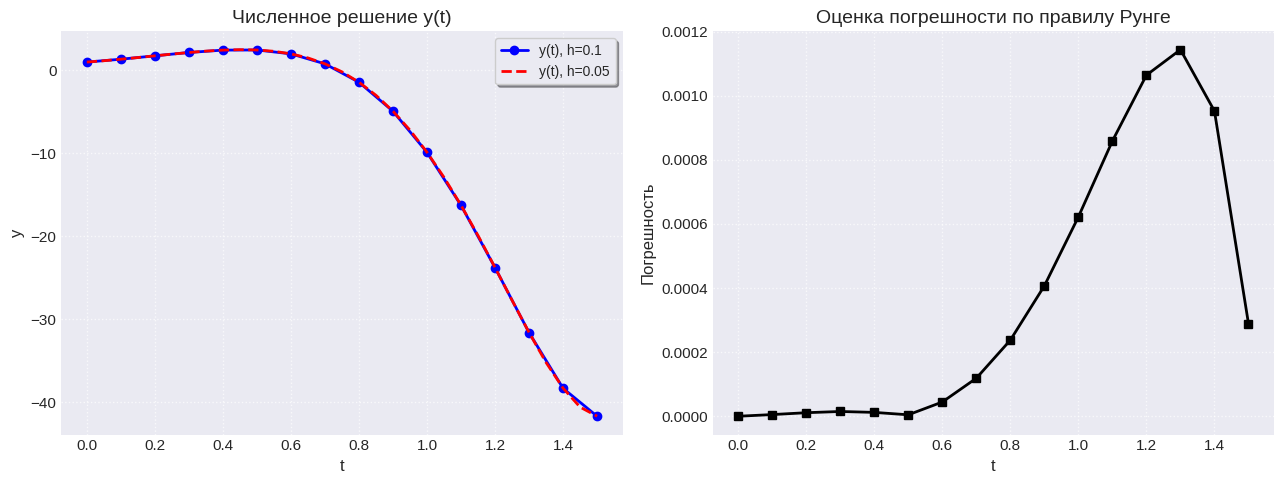

In [61]:
# Построение графика решения и оценки погрешности
plt.figure(figsize=(13, 5))

# --- График решения ---
plt.subplot(1, 2, 1)
plt.plot(t1, y1, marker='o', linestyle='-', color='blue', linewidth=2, label='y(t), h=0.1')
plt.plot(t2, y2, linestyle='--', color='red', linewidth=2, label='y(t), h=0.05')

plt.title('Численное решение y(t)', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10, frameon=True, shadow=True)

# --- График погрешности ---
plt.subplot(1, 2, 2)
plt.plot(t1, runge_error, marker='s', linestyle='-', color='black', linewidth=2)
plt.title('Оценка погрешности по правилу Рунге', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('Погрешность', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


In [60]:
print(f"Максимальная оценка погрешности: {np.max(runge_error):.2e}")

Максимальная оценка погрешности: 1.14e-03


# Задача 2.7. Анализ жестких систем ОДУ

**Дано:**  
Две задачи Коши для систем ОДУ 1 порядка с постоянными коэффициентами на отрезке [0, 1]:

\[
\begin{cases}
Y'(t) = AY(t) \\
Y(0) = Y_0
\end{cases}
\quad
\begin{cases}
Z'(t) = BZ(t) \\
Z(0) = Z_0
\end{cases}
\]

где \( A \) и \( B \) – заданные матрицы, \( Y_0, Z_0 \) – заданные векторы. Требуется выяснить, какая из задач является жесткой.

## Порядок решения:

1. **Явный метод Эйлера**  
   Составить программу-функцию решения системы ОДУ явным методом Эйлера. Решить обе задачи с шагом \( h=0.01 \). Определить, для какой задачи метод неустойчив.

2. **Анализ жесткости**  
   Найти собственные числа матриц \( A \) и \( B \), вычислить коэффициенты жесткости \( S_A \) и \( S_B \). Определить жесткую систему.

3. **Теоретическая оценка шага**  
   Для жесткой системы оценить шаг \( h^* \), при котором явный метод Эйлера устойчив (см. Приложение С).

4. **Неявный метод Эйлера**  
   Составить программу-функцию решения системы ОДУ неявным методом Эйлера. Решить жесткую задачу с \( h=0.01 \). Построить графики компонент решения.

5. **Сравнительный анализ**  
   Для жесткой задачи подобрать шаг \( h \), при котором решения явного и неявного методов визуально совпадают. Сравнить с \( h^* \). Объяснить различие в поведении методов.

## Примечание:  
Жесткой считается система, у которой коэффициент жесткости \( S = \frac{|\lambda_{max}|}{|\lambda_{min}|} > 10^3 \), где \( \lambda \) – собственные значения матрицы системы. Для явного метода Эйлера условие устойчивости: \( h < \frac{2}{|\lambda_{max}|} \).

In [62]:
from scipy.linalg import eig

# Заданные матрицы и начальные условия
A = np.array([[-229.934, 301.266],
              [227.624, -303.576]])
Y0 = np.array([1, 1])

B = np.array([[-2.018, -0.818],
              [-0.082, -1.282]])
Z0 = np.array([1, 1])



In [63]:
# 1. Анализ жесткости систем
def analyze_stiffness(matrix, name):
    eigenvalues = eig(matrix)[0]
    lambda_max = max(abs(eigenvalues))
    lambda_min = min(abs(eigenvalues))
    stiffness_ratio = lambda_max / lambda_min
    print(f"\nАнализ матрицы {name}:")
    print(f"Собственные значения: {eigenvalues}")
    print(f"λ_max: {lambda_max:.4f}, λ_min: {lambda_min:.4f}")
    print(f"Коэффициент жесткости S: {stiffness_ratio:.4f}")
    print("Жесткая система" if stiffness_ratio > 1000 else "Нежесткая система")
    return lambda_max, stiffness_ratio

lambda_max_A, S_A = analyze_stiffness(A, "A")
lambda_max_B, S_B = analyze_stiffness(B, "B")



Анализ матрицы A:
Собственные значения: [  -2.31+0.j -531.2 +0.j]
λ_max: 531.2000, λ_min: 2.3100
Коэффициент жесткости S: 229.9567
Нежесткая система

Анализ матрицы B:
Собственные значения: [-2.1+0.j -1.2+0.j]
λ_max: 2.1000, λ_min: 1.2000
Коэффициент жесткости S: 1.7500
Нежесткая система


In [64]:

# 2. Теоретическая оценка шага для явного метода Эйлера
h_star_A = 2 / lambda_max_A
h_star_B = 2 / lambda_max_B
print(f"\nТеоретический устойчивый шаг для системы A: {h_star_A:.6f}")
print(f"Теоретический устойчивый шаг для системы B: {h_star_B:.6f}")




Теоретический устойчивый шаг для системы A: 0.003765
Теоретический устойчивый шаг для системы B: 0.952381


In [65]:
# 3. Решение систем методами Эйлера
def explicit_euler(matrix, y0, t_span, h):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros((len(y0), len(t)))
    y[:, 0] = y0
    for i in range(1, len(t)):
        y[:, i] = y[:, i-1] + h * matrix @ y[:, i-1]
    return t, y

def implicit_euler(matrix, y0, t_span, h):
    t = np.arange(t_span[0], t_span[1] + h, h)
    y = np.zeros((len(y0), len(t)))
    y[:, 0] = y0
    I = np.eye(len(y0))
    for i in range(1, len(t)):
        y[:, i] = np.linalg.solve(I - h * matrix, y[:, i-1])
    return t, y



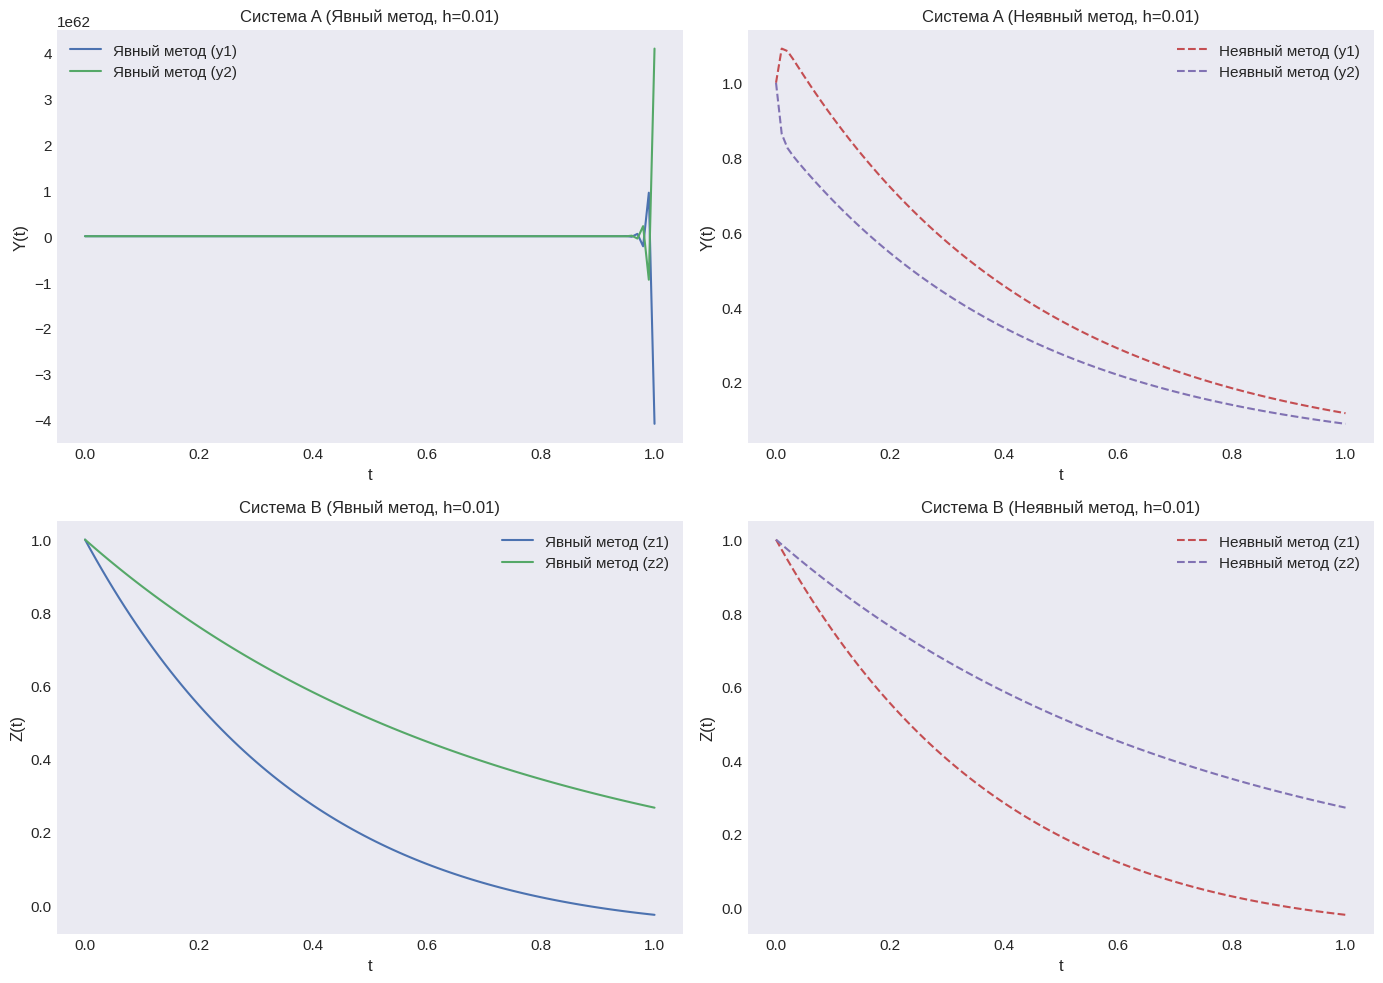

In [67]:
# Параметры решения
t_span = [0, 1]
h = 0.01

# Решение систем
t_A_exp, Y_exp = explicit_euler(A, Y0, t_span, h)
t_A_imp, Y_imp = implicit_euler(A, Y0, t_span, h)
t_B_exp, Z_exp = explicit_euler(B, Z0, t_span, h)
t_B_imp, Z_imp = implicit_euler(B, Z0, t_span, h)

# 4. Визуализация результатов
plt.figure(figsize=(14, 10))

# Система A
plt.subplot(2, 2, 1)
plt.plot(t_A_exp, Y_exp[0], 'b-', label='Явный метод (y1)')
plt.plot(t_A_exp, Y_exp[1], 'g-', label='Явный метод (y2)')
plt.title(f'Система A (Явный метод, h={h})')
plt.xlabel('t')
plt.ylabel('Y(t)')
plt.legend()
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(t_A_imp, Y_imp[0], 'r--', label='Неявный метод (y1)')
plt.plot(t_A_imp, Y_imp[1], 'm--', label='Неявный метод (y2)')
plt.title(f'Система A (Неявный метод, h={h})')
plt.xlabel('t')
plt.ylabel('Y(t)')
plt.legend()
plt.grid()

# Системa B
plt.subplot(2, 2, 3)
plt.plot(t_B_exp, Z_exp[0], 'b-', label='Явный метод (z1)')
plt.plot(t_B_exp, Z_exp[1], 'g-', label='Явный метод (z2)')
plt.title(f'Система B (Явный метод, h={h})')
plt.xlabel('t')
plt.ylabel('Z(t)')
plt.legend()
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(t_B_imp, Z_imp[0], 'r--', label='Неявный метод (z1)')
plt.plot(t_B_imp, Z_imp[1], 'm--', label='Неявный метод (z2)')
plt.title(f'Система B (Неявный метод, h={h})')
plt.xlabel('t')
plt.ylabel('Z(t)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()



In [68]:
# 5. Подбор шага для явного метода (для жесткой системы)
if S_A > 1000:
    print("\nПодбор шага для системы A (жесткой):")
    for h_test in [1e-4, 5e-5, 1e-5]:
        t_test, Y_test = explicit_euler(A, Y0, t_span, h_test)
        error = np.max(np.abs(Y_test[:, -1] - Y_imp[:, -1]))
        print(f"h = {h_test:.0e}, ошибка = {error:.4f}")

#**Задача 2.8.**
 Решить приближенно задачу Коши для ОДУ 1 порядка вида (1) с помощью
метода, указанного в индивидуальном варианте, с точностью $epsilon=10^{-4}$
При нахождении
решения использовать алгоритм автоматического выбора шага (Сделать переход к длине
дуги кривой и процедуру автономизации)

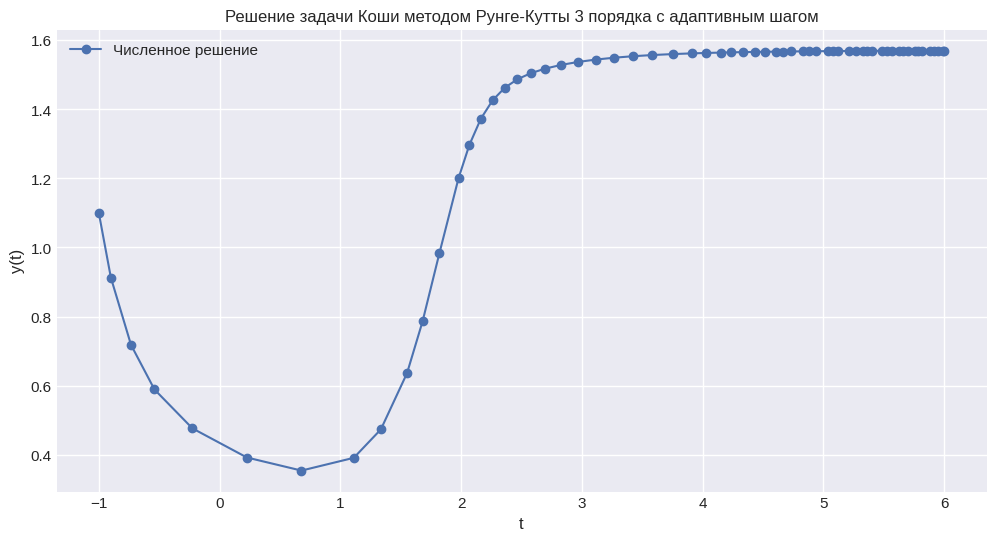

In [69]:
# Правая часть ОДУ
def f(t, y):
    return (1/3) * t**3 * np.sin(2 * y) - y**2 * np.exp(-t / 2)

# Метод Рунге-Кутты 3-го порядка
def runge_kutta3_step(t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h/2 * k1)
    k3 = f(t + h, y - h * k1 + 2 * h * k2)
    return y + h / 6 * (k1 + 4 * k2 + k3)

# Адаптивный метод с контролем точности по правилу Рунге
def solve_adaptive_rk3(f, t0, y0, T, eps):
    t_vals = [t0]
    y_vals = [y0]
    h = 0.1  # начальный шаг
    t = t0
    y = y0

    while t < T:
        if t + h > T:
            h = T - t

        # Один шаг с шагом h
        y1 = runge_kutta3_step(t, y, h)

        # Два шага с шагом h/2
        y_half = runge_kutta3_step(t, y, h/2)
        y2 = runge_kutta3_step(t + h/2, y_half, h/2)

        # Оценка ошибки
        error = np.abs(y2 - y1) / 7  # Погрешность 3-го порядка

        # Уточнение шага
        if error < eps:
            t += h
            y = y2
            t_vals.append(t)
            y_vals.append(y)

        # Изменение шага
        if error == 0:
            s = 2
        else:
            s = (eps / error) ** (1/3)

        h *= min(max(0.5, s), 2.0)  # ограничение на рост/уменьшение шага

    return np.array(t_vals), np.array(y_vals)

# Параметры задачи
t0 = -1
T = 6
y0 = 1.1
eps = 1e-4

# Решение
t_vals, y_vals = solve_adaptive_rk3(f, t0, y0, T, eps)

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(t_vals, y_vals, 'bo-', label='Численное решение')
plt.title('Решение задачи Коши методом Рунге-Кутты 3 порядка с адаптивным шагом')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.grid(True)
plt.legend()
plt.show()
